## Decision Tree Classifier (Scikit-learn)

#### Decision Tree Algorithm

A decision tree is a flowchart-like tree structure where an internal node represents feature (or attribute), the branch represents a decision rule, and each leaf node represents the outcome. The topmost node in a decision tree is known as the root node. It learns to partition on the basis of the attribute value. It partitions the tree in recursive manner called recursive partitioning. This flowchart-like structure helps you in decision making. It's visualization like a flowchart diagram which easily mimics the human level thinking. That is why decision trees are easy to understand and interpret.
Decision Tree is a white box type of ML algorithm. It shares internal decision-making logic, which is not available in the black box type of algorithms such as Neural Network. Its training time is faster compared to the neural network algorithm. The time complexity of decision trees is a function of the number of records and number of attributes in the given data. The decision tree is a distribution-free or non-parametric method, which does not depend upon probability distribution assumptions. Decision trees can handle high dimensional data with good accuracy.

#### How does the Decision Tree algorithm work?

The basic idea behind any decision tree algorithm is as follows:

1. Select the best attribute using Attribute Selection Measures(ASM) to split the records.
2. Make that attribute a decision node and breaks the dataset into smaller subsets.
3. Start tree building by repeating this process recursively for each child until one of the condition will match:
- all the tuples belong to the same attribute value.
- there are no more remaining attributes.
- there are no more instances

#### Attribute Selection Measures (ASM)

Attribute selection measure is a heuristic for selecting the splitting criterion that partition data into the best possible manner. It is also known as splitting rules because it helps us to determine breakpoints for tuples on a given node. ASM provides a rank to each feature (or attribute) by explaining the given dataset. Best score attribute will be selected as a splitting attribute. In the case of a continuous-valued attribute, split points for branches also need to be defined. Most popular selection measures are Information Gain, Gain Ratio, and Gini Index.

#### Information Gain

Shannon invented the concept of entropy, which measures the impurity of the input set. In physics and mathematics, entropy is referred to as the randomness or the impurity in the system. In information theory, it refers to the impurity in a group of examples. Information gain is the decrease in entropy. Information gain computes the difference between entropy before split and average entropy after split of the dataset based on given attribute values. ID3 (Iterative Dichotomiser) decision tree algorithm uses information gain.

#### Gain Ratio

Information gain is biased for the attribute with many outcomes. It means it prefers the attribute with a large number of distinct values. For instance, consider an attribute with an unique identifier such as customer_ID, which has zero info(D) because of pure partition. This maximizes the information gain and creates useless partitioning.
C4.5, an improvement of ID3, uses an extension to information gain known as the gain ratio. Gain ratio handles the issue of bias by normalizing the information gain using Split Info. Java implementation of the C4.5 algorithm is known as J48, which is available in WEKA data mining tool.

#### Gini Index

Another decision tree algorithm CART (Classification and Regression Tree) uses the Gini method to create split points.
The Gini Index considers a binary split for each attribute. You can compute a weighted sum of the impurity of each partition.
In case of a discrete-valued attribute, the subset that gives the minimum gini index for that chosen is selected as a splitting attribute. In the case of continuous-valued attributes, the strategy is to select each pair of adjacent values as a possible split-point and point with smaller gini index chosen as the splitting point.

In [9]:
# load libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [10]:
# helper list
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi',
             'pedigree', 'age', 'label']
# load data
pima = pd.read_csv('./datasets/diabetes.csv', header = None, names = col_names)

In [14]:
pima = pima.drop(pima.index[0])
pima.head()

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0
5,0,137,40,35,168,43.1,2.288,33,1


In [16]:
# split dataset in features and target viariable
feature_cols = ['pregnant', 'insulin', 'bmi', 'age', 'glucose',
                'bp', 'pedigree']
X = pima[feature_cols] # features
y = pima.label # target variable

In [17]:
# split dataset into training set and test set
# 70% training set and 30% test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3,
                                                    random_state = 1)

In [18]:
# create decision tree classifier object
clf = DecisionTreeClassifier()

# train decision tree classifier
clf = clf.fit(X_train, y_train)

# predict the response for test dataset
y_pred = clf.predict(X_test)

In [20]:
# model accuracy, how often is the classifier correct?
print('Accuracy: {:.2%}'.format(metrics.accuracy_score(y_test, y_pred)))

Accuracy: 65.37%


In [22]:
# visualizing decision trees:
# skcikit-learn's export graphviz function
# pydotplus
# export_graphviz function converts decision tree classifier into dot file
# pydotplus converts this dot file to png or displayable form on Jupyter
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
import pydotplus

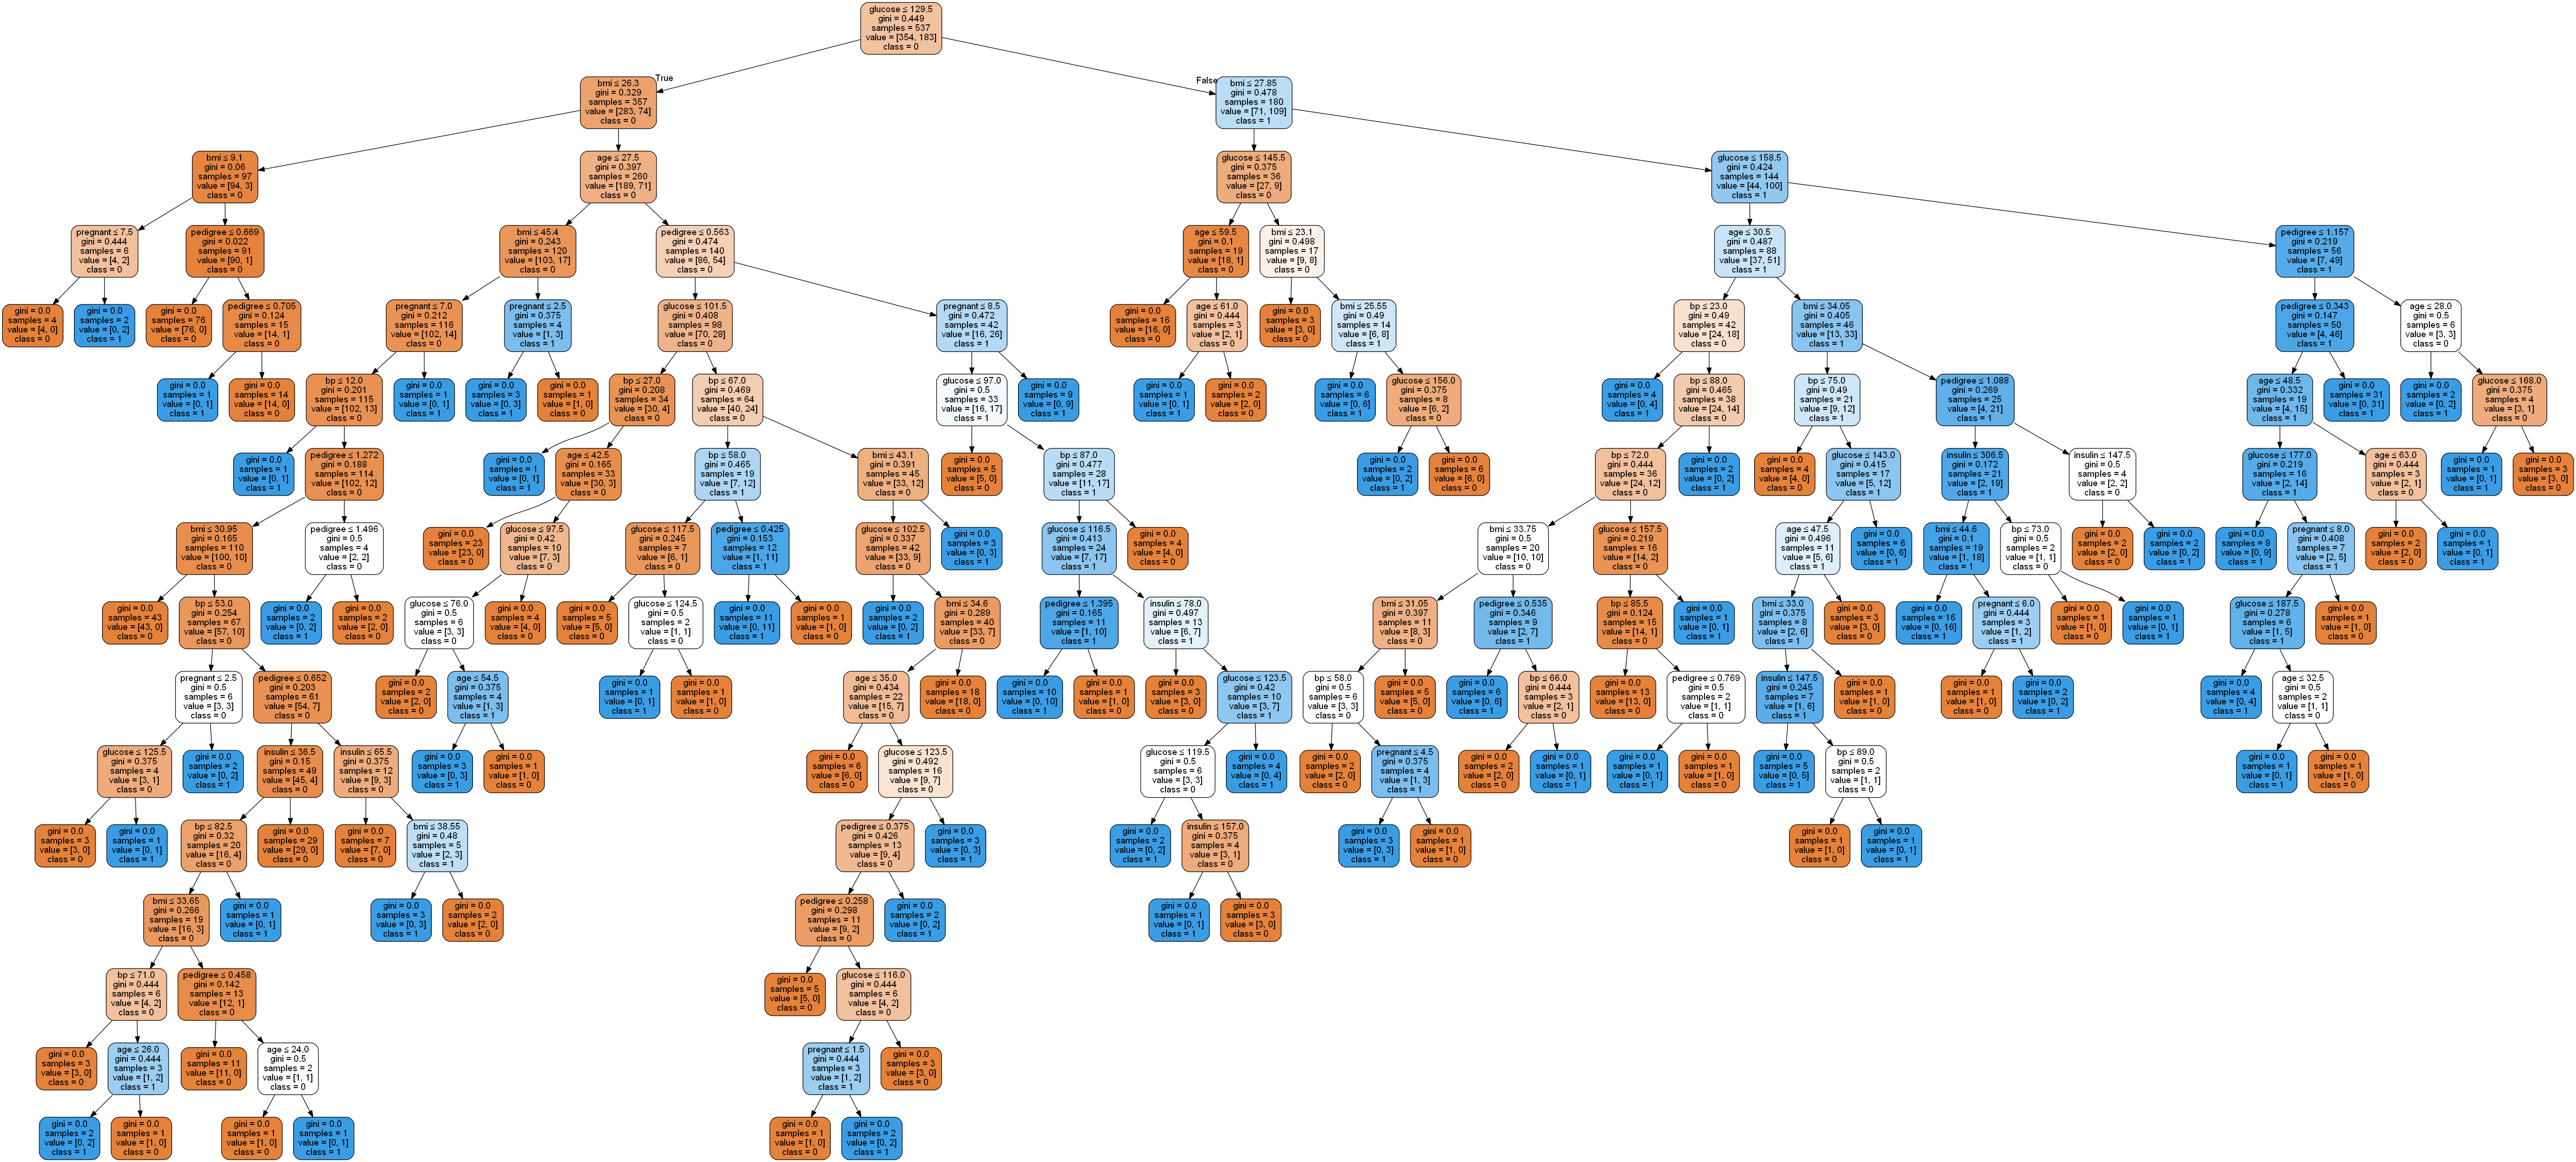

In [23]:
dot_data = StringIO()
export_graphviz(clf, out_file = dot_data, filled = True, rounded = True,
                special_characters = True, feature_names = feature_cols,
                class_names = ['0', '1'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('diabetes.png')
Image(graph.create_png())

In the decision tree chart, each internal node has a decision rule that splits
the data. Gini referred to as Gini ratio, which measures the impurity
of the node. You can say a node is pure when all of its records belong
to the same class, such nodes known as the leaf node. Here, the resultant
tree is unpruned. This unpruned tree is unexplainableand not easy to understand. In the next section, let's optimize it by pruning.

#### Optimizing Decision Tree Performance

- criterion: optional (default='gini') or Choose attribute selection measure: This parameter allows us to use the different-different attribute selection measure. Supported criteria are 'gini' for the Gini index and 'entropy' for the information gain.
- splitter: string, optional (default='best') or Split strategy: This parameter allows us to choose the split strategy. Supported strategies are 'best' to choose the best split and 'random' to choose the best random split.
- max_depth: int or None, optional (default=None) or Maximum Depth of a Tree: The maximum depth of the tree. If None, then nodes are expanded until all the leaves contain less than min_samples_split samples. The higher value of maximum depth causes overfitting and a lower value causes underfitting.

In Scikit-learn, optimization of decision tree classifier is performed only by pre-prunning.

In [24]:
# create decision tree classifier object
clf_new = DecisionTreeClassifier(criterion = 'entropy', max_depth = 3)

# train decision tree classifier
clf_new = clf_new.fit(X_train, y_train)

# predict the response for test dataset
y_pred_new = clf_new.predict(X_test)

In [25]:
# model accuracy, how often is the classifier correct?
print('accuracy: {:.2%}'.format(metrics.accuracy_score(y_test, y_pred_new)))

accuracy: 77.06%


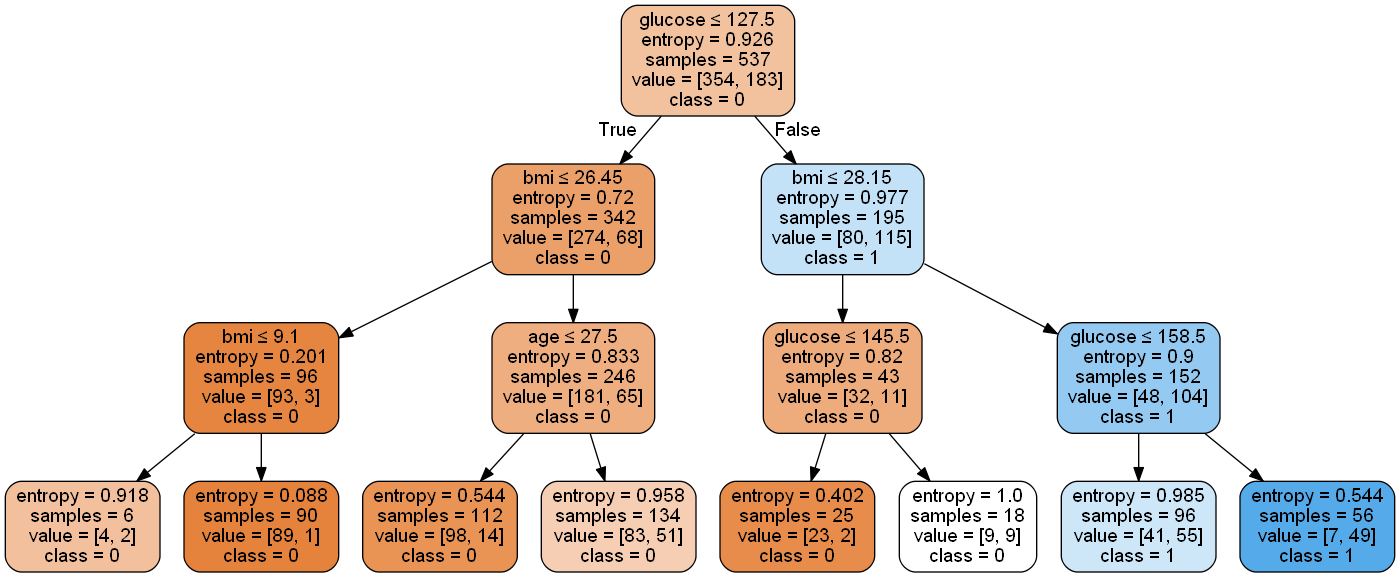

In [27]:
# visualizing decision tree
dot_data_new = StringIO()
export_graphviz(clf_new, out_file = dot_data_new, filled = True,
                rounded = True, special_characters = True,
                feature_names = feature_cols, class_names = ['0', '1'])
graph_new = pydotplus.graph_from_dot_data(dot_data_new.getvalue())
graph_new.write_png('diabetes_new.png')
Image(graph_new.create_png())

This pruned model is less complex, explainable and easier to understand than the previous decision tree model plot.

#### Pros

- decision trees are easy to interpret and visualize
- it can easily capture non-linear paterns
- it requires fewer data preprocessing from the user, for instance, there is no need to normalize columns
- it can be used for feature engineering such as predicting missing values, suitable for variable selection
- the decision tree has no assumptions about distribution because of            the non-parametric nature of the algorithm

#### Cons

- sensitive to noisy data - it can overfit noisy data
- the small variation (or variance) in data can result in the different decision tree. This can be reduced by bagging and boosting algorithms
- decision trees are biased with imbalance dataset, so it is recommended to balance out the dataset before creating the decision tree